# Mitigation for Trotter errors

In this notebook, we focus on the regime where the total time $T$ is small ($T < 1.0$).  
For each total time $T_{\text{total}}$, we execute quantum circuits using various time steps $dt$, which correspond to different numbers of Trotter steps.  
To estimate the expectation values in the limit of $dt \to 0$, the observed values obtained for $dt$ between $T/6$ and $T/2$ are extrapolated using a quadratic fit.

## Setup

In [45]:
!pip list 

/opt/homebrew/Cellar/python@3.11/3.11.5/Frameworks/Python.framework/Versions/3.11/lib/python3.11/pty.py:89: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid, fd = os.forkpty()


Package                                  Version
---------------------------------------- -----------
aiohappyeyeballs                         2.6.1
aiohttp                                  3.13.2
aiohttp-cors                             0.8.1
aiosignal                                1.4.0
annotated-types                          0.7.0
anyio                                    4.11.0
appnope                                  0.1.4
argon2-cffi                              25.1.0
argon2-cffi-bindings                     25.1.0
arrow                                    1.4.0
asttokens                                3.0.0
async-lru                                2.0.5
attrs                                    25.4.0
babel                                    2.17.0
backports.zstd                           1.3.0
beautifulsoup4                           4.14.2
bleach                                   6.2.0
cachetools                               6.2.4
certifi                                  2024

In [42]:
import sys
sys.path.append('../')

import numpy as np
import scipy
import jax
import jax.numpy as jnp
from qiskit import QuantumCircuit, transpile
from qiskit.circuit import Parameter
from qiskit.transpiler import PassManager, StagedPassManager, generate_preset_pass_manager
from qiskit.quantum_info import Operator
from qiskit_ibm_runtime.fake_provider import FakeTorino, FakeKawasaki
from qiskit_aer import AerSimulator

import lsh_qudit.set_rccx_inverse
from lsh_qudit.validator_jax import validate_circuit
from lsh_qudit.agl import physical_states, boundary_conditions
from lsh_qudit.hamiltonian_nn import (mass_term, electric_12_term,
                                            electric_3f_term, electric_3b_term,
                                            hopping_term_config, hopping_term_site)
from lsh_qudit.matrices import hopping_site_hamiltonian
from lsh_qudit.trotter_nn import trotter_step_circuit
from lsh_qudit.precompiler import lsh_qudit_precompiler
precompile_pm = lsh_qudit_precompiler()

jax.config.update('jax_enable_x64', True)

mass_mu = Parameter('$\mu$')
interaction_x = Parameter('x')
time_step = Parameter('$\Delta$t')

num_sites = 4
mu = 1.00
x = 1.00

## Useful functions

In [3]:
def energy_density(probs, shape):
    dim = np.prod(shape)
    offsets = np.cumprod((1,) + shape[:0:-1])[::-1]
    nvals = (np.arange(dim)[:, None] // offsets[None, :]) % np.array(shape)[None, :]
    nvals = np.flip(nvals, axis=1)
    ni = nvals[:, ::3]
    no = nvals[:, 1::3]
    nl = nvals[:, 2::3]
    site_energy_densities = (nl / 2. + nl * nl / 4. + (nl + 1.5) * no * (1 - ni) / 2.)
    extra_dims = tuple(range(probs.ndim - 1))
    expval = np.sum(probs[..., None] * np.expand_dims(site_energy_densities, extra_dims), axis=-2)
    return expval

In [4]:
def CalcExpectation_Old(probs, post_select_level=0):
    nBit = len(list(probs.keys())[0])
    vExp = list()
    Norm = list()
    nDiscard=0
    
    for i in range(6):
        vExp.append(0)
        Norm.append(0)
    
    for i in probs:
        Nl0 = 0
        No0 = int(i[12], 2)
        Ni0 = int(i[11], 2)
        
        Nl1 = int(i[9], 2)
        No1 = int(i[8], 2)
        Ni1 = int(i[10], 2)

        Nl2 = int(i[0:2], 2)
        No2 = int(i[6], 2)
        Ni2 = int(i[5], 2)

        Nl3 = int(i[3], 2)
        No3 = int(i[2], 2)
        Ni3 = int(i[4], 2)

        N_L0 = Nl0 + No0*(1.0 - Ni0)
        N_L1 = Nl1 + No1*(1.0 - Ni1)
        N_L2 = Nl2 + No2*(1.0 - Ni2)
        N_Lfix = Nl3 + No3*(1.0 - Ni3)

        N_Rfix = Nl0 + Ni0*(1.0 - No0)
        N_R0 = Nl1 + Ni1*(1.0 - No1)
        N_R1 = Nl2 + Ni2*(1.0 - No2)
        N_R2 = Nl3 + Ni3*(1.0 - No3)
        
        if post_select_level>0:
            if post_select_level==1 or post_select_level==3:
                if int(i[7])!=0:
                    nDiscard += probs[i]
                    continue
            if post_select_level==2 or post_select_level==3:
                if N_L0!=N_R0 or N_L1!=N_R1 or N_L2!=N_R2:
                    nDiscard+=probs[i]
#                    print(f'{N_L0}, {N_R0}, {N_L1}, {N_R1}, {N_L2}, {N_R2}')
                    continue

        vExp[5] += (N_Rfix/2.0)*(N_Rfix/2.0 + 1)*probs[i]
        Norm[5] += probs[i]

        
        # site = 0
        Ni = int(i[11], 2)
        No = int(i[12], 2)
        N_L = 3.0 * (1.0 + (-1)**Ni - (-1)**No - ((-1)**Ni)*((-1)**No) )/16.0
        vExp[0] += N_L * probs[i]
        Norm[0] += probs[i]

        # site = 1
        Ni = int(i[10], 2)
        No = int(i[8], 2)
        Nl0 = int(i[9], 2)
        N_L = (10.0 + 4.0*((-1)**Ni) - 4.0*((-1)**No) - 4.0*((-1)**No)*((-1)**Ni) - 7.0*((-1)**Nl0) - ((-1)**Nl0)*((-1)**Ni) + ((-1)**Nl0)*((-1)**No) + ((-1)**Nl0)*((-1)**No)*((-1)**Ni) )/16.0
        vExp[1] += N_L * probs[i]
        Norm[1] += probs[i]
        
        # site = 2
        Ni = int(i[5], 2)
        No = int(i[6], 2)
        Nl0 = int(i[1], 2)
        Nl1 = int(i[0], 2)
        N_L = (32.0 + 6.0*((-1)**Ni) - 6.0*((-1)**No) - 6.0*((-1)**No)*((-1)**Ni) - 11.0*((-1)**Nl0) - ((-1)**Nl0)*((-1)**Ni) + ((-1)**Nl0)*((-1)**No) + ((-1)**Nl0)*((-1)**No)*((-1)**Ni) - 22.0*((-1)**Nl1) - 2.0*((-1)**Nl1)*((-1)**Ni) + 2.0*((-1)**Nl1)*((-1)**No) + 2.0*((-1)**Nl1)*((-1)**No)*((-1)**Ni) + 4.0*((-1)**Nl1)*((-1)**Nl0))/16.0
#        N_L = (6.0*((-1)**Ni) - 6.0*((-1)**No) - 6.0*((-1)**No)*((-1)**Ni) - 11.0*((-1)**Nl0) - ((-1)**Nl0)*((-1)**Ni) + ((-1)**Nl0)*((-1)**No) + ((-1)**Nl0)*((-1)**No)*((-1)**Ni) - 22.0*((-1)**Nl1) - 2.0*((-1)**Nl1)*((-1)**Ni) + 2.0*((-1)**Nl1)*((-1)**No) + 2.0*((-1)**Nl1)*((-1)**No)*((-1)**Ni) + 4.0*((-1)**Nl1)*((-1)**Nl0))/16.0
        vExp[2] += N_L * probs[i]
        Norm[2] += probs[i]

        # site = 3
        Ni = int(i[4], 2)
        No = int(i[2], 2)
        Nl0 = int(i[3], 2)
        N_L = (10.0 + 4.0*((-1)**Ni) - 4.0*((-1)**No) - 4.0*((-1)**No)*((-1)**Ni) - 7.0*((-1)**Nl0) - ((-1)**Nl0)*((-1)**Ni) + ((-1)**Nl0)*((-1)**No) + ((-1)**Nl0)*((-1)**No)*((-1)**Ni) )/16.0
        vExp[3] += N_L * probs[i]
        Norm[3] += probs[i]
        
        # ancilla
        anc = int(i[7], 2)
        vExp[4] += anc * probs[i]
        Norm[4] += probs[i]

    print(f'# of discarded = {nDiscard}')

    for i in range(6):
        vExp[i] = vExp[i]/Norm[i]
        print(f'site {i} : {vExp[i]}')
        
    return vExp

In [5]:
def CalEFieldEnergy_quantinuum(dist, fPostSelect=0):
    nShots=dist.total
    nDiscard=0
    nBit=13-1
    nAnc = 1
    SumEnergy = 0
    EF_List = list()
    Norm = list()
    for i in range(5):
        EF_List.append(0)
        Norm.append(0)

    for i in dist.as_counter().keys():
        counts=dist.as_counter()[i]        
        bitstr=''
        for j in range(len(i)):
            bitstr+=str(i[j])

#        print(f'{bitstr} = {counts}')

        Nl0 = 0
        No0 = int(bitstr[nBit-12], 2)
        Ni0 = int(bitstr[nBit-11], 2)
        
        Nl1 = int(bitstr[nBit-9], 2)
        No1 = int(bitstr[nBit-8], 2)
        Ni1 = int(bitstr[nBit-10], 2)

        Nl2 = int(bitstr[nBit-0:nBit-2:-1], 2)
        No2 = int(bitstr[nBit-6], 2)
        Ni2 = int(bitstr[nBit-5], 2)

        Nl3 = int(bitstr[nBit-3], 2)
        No3 = int(bitstr[nBit-2], 2)
        Ni3 = int(bitstr[nBit-4], 2)

        N_L0 = Nl0 + No0*(1.0 - Ni0)
        N_L1 = Nl1 + No1*(1.0 - Ni1)
        N_L2 = Nl2 + No2*(1.0 - Ni2)
        N_Lfix = Nl3 + No3*(1.0 - Ni3)

        N_Rfix = Nl0 + Ni0*(1.0 - No0)
        N_R0 = Nl1 + Ni1*(1.0 - No1)
        N_R1 = Nl2 + Ni2*(1.0 - No2)
        N_R2 = Nl3 + Ni3*(1.0 - No3)

        iE = 0
        if fPostSelect>0:
            if fPostSelect==1 or fPostSelect==3:
                if int(bitstr[nBit-7])!=0:
    #                print("Ancillae are not zero!!")
                    nDiscard+=counts
                    continue
            if fPostSelect==2 or fPostSelect==3:
                if N_L0!=N_R0 or N_L1!=N_R1 or N_L2!=N_R2:
                    nDiscard+=counts
                    continue
    
#            if bitstr[nBit-0:nBit-2:-1]=='11':
#                print("Unexpected value: Nl(2)==11")
#                nDiscard+=1
#                continue

#        Nl = int(bitstr[3], 2)
#        No = int(bitstr[2], 2)
#        Ni = int(bitstr[4], 2)

        EF_List[4] += (N_Rfix/2.0)*(N_Rfix/2.0 + 1)*counts
        Norm[4]    += counts
        
        Nl = int(bitstr[nBit-3], 2)
        No = int(bitstr[nBit-2], 2)
        Ni = int(bitstr[nBit-4], 2)
        N_L = Nl + No*(1.0 - Ni)
        EF_List[3] += (N_L/2.0)*(N_L/2.0 + 1)*counts
        Norm[3]    += counts
#        print(f"site3: N_L = {N_L}, {(counts/nShots)}")

#        Nl = int(bitstr[0:2], 2)
#        No = int(bitstr[6], 2)
#        Ni = int(bitstr[5], 2)
        Nl = int(bitstr[nBit-0:nBit-2:-1], 2)
        No = int(bitstr[nBit-6], 2)
        Ni = int(bitstr[nBit-5], 2)
        N_L = Nl + No*(1.0 - Ni)
        EF_List[2] += (N_L/2.0)*(N_L/2.0 + 1)*counts
        Norm[2]    += counts
#        print(f"site2: N_L = {N_L}, {(counts/nShots)}")

#        Nl = int(bitstr[9], 2)
#        No = int(bitstr[8], 2)
#        Ni = int(bitstr[10], 2)
        Nl = int(bitstr[nBit-9], 2)
        No = int(bitstr[nBit-8], 2)
        Ni = int(bitstr[nBit-10], 2)
        N_L = Nl + No*(1.0 - Ni)
        EF_List[1] += (N_L/2.0)*(N_L/2.0 + 1)*counts
        Norm[1]    += counts
#        print(f"site1: N_L = {N_L}, {(counts/nShots)}")

#        Nl = 0
#        No = int(bitstr[12], 2)
#        Ni = int(bitstr[11], 2)
        Nl = 0
        No = int(bitstr[nBit-12], 2)
        Ni = int(bitstr[nBit-11], 2)
        N_L = Nl + No*(1.0 - Ni)
        EF_List[0] += (N_L/2.0)*(N_L/2.0 + 1)*counts
        Norm[0]    += counts
#        print(f"site0: N_L = {N_L}, {(counts/nShots)}")

    print(f'# of discarded = {nDiscard}')
    for i in range(5):
        EF_List[i] = EF_List[i]/Norm[i]
        print(f'site {i} : {EF_List[i]}')
    return EF_List

In [6]:
def DumpInfoQnx(dist, filename="Qnx.txt"):
    nBit = 13 - 1

    for i in dist.as_counter().keys():
        counts=dist.as_counter()[i]        
        bitstr=''
        for j in range(len(i)):
            bitstr+=str(i[j])

#        print(f'{bitstr} = {counts}')
        Nl0 = 0
        No0 = int(bitstr[nBit-12], 2)
        Ni0 = int(bitstr[nBit-11], 2)
        
        Nl1 = int(bitstr[nBit-9], 2)
        No1 = int(bitstr[nBit-8], 2)
        Ni1 = int(bitstr[nBit-10], 2)

        Nl2 = int(bitstr[nBit-0:nBit-2:-1], 2)
        anc = int(bitstr[nBit-7], 2)
        No2 = int(bitstr[nBit-6], 2)
        Ni2 = int(bitstr[nBit-5], 2)
        
        Nl3 = int(bitstr[nBit-3], 2)
        No3 = int(bitstr[nBit-2], 2)
        Ni3 = int(bitstr[nBit-4], 2)

        N_L0 = Nl0 + No0*(1.0 - Ni0)
        N_L1 = Nl1 + No1*(1.0 - Ni1)
        N_L2 = Nl2 + No2*(1.0 - Ni2)
        N_Lfix = Nl3 + No3*(1.0 - Ni3)

        N_Rfix = Nl0 + Ni0*(1.0 - No0)
        N_R0 = Nl1 + Ni1*(1.0 - No1)
        N_R1 = Nl2 + Ni2*(1.0 - No2)
        N_R2 = Nl3 + Ni3*(1.0 - No3)

        with open(filename, mode="a") as f:
            print(f'{N_L0} {N_L1} {N_L2} {N_Lfix} {N_R0} {N_R1} {N_R2} {N_Rfix} {anc} {counts}', file=f)

In [46]:
def DumpInfoIBM(probs, filename="IBM.txt"):
    nBit = len(list(probs.keys())[0])
    vExp = list()
    Norm = list()
    nDiscard=0
    
    for i in range(6):
        vExp.append(0)
        Norm.append(0)

    for i in probs:
        Nl0 = 0
        No0 = int(i[12], 2)
        Ni0 = int(i[11], 2)
        
        Nl1 = int(i[9], 2)
        No1 = int(i[8], 2)
        Ni1 = int(i[10], 2)

        Nl2 = int(i[0:2], 2)
        No2 = int(i[6], 2)
        Ni2 = int(i[5], 2)

        Nl3 = int(i[3], 2)
        No3 = int(i[2], 2)
        Ni3 = int(i[4], 2)

        anc = int(i[7], 2)

        N_L0 = Nl0 + No0*(1.0 - Ni0)
        N_L1 = Nl1 + No1*(1.0 - Ni1)
        N_L2 = Nl2 + No2*(1.0 - Ni2)
        N_Lfix = Nl3 + No3*(1.0 - Ni3)

        N_Rfix = Nl0 + Ni0*(1.0 - No0)
        N_R0 = Nl1 + Ni1*(1.0 - No1)
        N_R1 = Nl2 + Ni2*(1.0 - No2)
        N_R2 = Nl3 + Ni3*(1.0 - No3)

        with open(filename, mode="a") as f:
            print(f'{N_L0} {N_L1} {N_L2} {N_Lfix} {N_R0} {N_R1} {N_R2} {N_Rfix} {anc} {int(100000*probs[i]+0.00001)}', file=f)


In [49]:
import json
import datetime
import qnexus as qnx

TList = [0.2, 0.4, 0.6, 0.8, 1.0]
PROJECT_NAME = "LSH_LGT"
SAVE_FILE = f"../savefiles/qnexus_trotter_sf1_job_ids.json"
N_SHOTS = 1000

project = qnx.projects.get_or_create(name=PROJECT_NAME)
qnx.context.set_active_project(project)

job_records = []


full_circuit = trotter_step_circuit(num_sites, time_step, mass_mu, interaction_x, qp=full_qp,
                                    max_left_flux=0, max_right_flux=1, with_barrier=True)
qregs = []
for name, isite in full_circuit[1].qubit_labels:
    qregs.append(QuantumRegister(1, name=f'{name}({isite})'))


for tmax in TList:
    for i in range(6):
        nstep=i+1

        # Circuit construction
        qc = QuantumCircuit(*qregs)
        
        qc.data.insert(0, CircuitInstruction(XGate(label=None), [0], []))
        qc.data.insert(0, CircuitInstruction(XGate(label=None), [4], []))
        qc.data.insert(0, CircuitInstruction(XGate(label=None), [3], []))
        qc.data.insert(0, CircuitInstruction(XGate(label=None), [8], []))
        qc.data.insert(0, CircuitInstruction(XGate(label=None), [9], []))
        qc.data.insert(0, CircuitInstruction(XGate(label=None), [12], []))
        for _ in range(nstep):        
            qc.append(full_circuit[0].assign_parameters({mass_mu: mu, time_step: tmax/nstep, interaction_x: 1.00}), range(13))

        qc.measure_all()
        
        pm_ideal = generate_preset_pass_manager(backend=AerSimulator(), optimization_level=0)
        samplerV2_sim = Sampler(AerSimulator())
        result = samplerV2_sim.run([(pm_ideal.run(qc.decompose()))], shots=100000).result()[0]
        raw_counts   = result.data.meas.get_counts()
        prob_sim = {i: raw_counts[i]/100000 for i in raw_counts.keys()}
        print(f"Tmax = {tmax}, nstep = {nstep}, dt = {tmax/nstep}, # of gates per step = {qc.count_ops()}")
        print(CalcExpectation_Old(prob_sim, 0))
        DumpInfoIBM(prob_sim, f'../savefiles/Sim_trotterT{int(10*tmax)}_{nstep}step.txt')


Tmax = 0.2, nstep = 1, dt = 0.2, # of gates per step = OrderedDict([('measure', 13), ('x', 6), ('circuit-4135', 1), ('barrier', 1)])
# of discarded = 0
site 0 : 0.7488225000000002
site 1 : 1.9475525000000002
site 2 : 1.9485350000000006
site 3 : 0.7500000000000002
site 4 : 0.0
site 5 : 0.0
[0.7488225000000002, 1.9475525000000002, 1.9485350000000006, 0.7500000000000002, 0.0, 0.0]
Tmax = 0.2, nstep = 2, dt = 0.1, # of gates per step = OrderedDict([('measure', 13), ('x', 6), ('circuit-4142', 1), ('circuit-4145', 1), ('barrier', 1)])
# of discarded = 0
site 0 : 0.749385
site 1 : 1.9504599999999999
site 2 : 1.9493175
site 3 : 0.75
site 4 : 0.0
site 5 : 0.0
[0.749385, 1.9504599999999999, 1.9493175, 0.75, 0.0, 0.0]
Tmax = 0.2, nstep = 3, dt = 0.06666666666666667, # of gates per step = OrderedDict([('measure', 13), ('x', 6), ('circuit-4152', 1), ('circuit-4155', 1), ('circuit-4158', 1), ('barrier', 1)])
# of discarded = 0
site 0 : 0.7495575000000002
site 1 : 1.9500175000000002
site 2 : 1.949502

## Theoretical calculation

In [7]:
num_sites = 4
tmax = 1.
tpoints = np.linspace(0., tmax, 1001)
mu = 1.
x = 1.

# i(0), o(0), l(0), i(1), o(1), l(1), ...
initial_state = [0, 1, 0] + [0, 1, 1] + [0, 0, 2] + [1, 0, 1]

In [8]:
from jax.experimental.ode import odeint
from lsh_qudit.matrices import hamiltonian, hamiltonian_op, nl_bounds
# Function that computes H|psi>
hop = hamiltonian_op(num_sites, mu, x)

# Time derivative of exp(-iHt)|psi(0)>
def dpsidt(state, t):
    return -1.j * hop(state)

shape = (3, 2, 2) * num_sites
psi0 = np.zeros(shape, dtype=np.complex128)
psi0[tuple(initial_state[::-1])] = 1.
psi0 = psi0.reshape(-1)

# Solve the Schrodinger equation
states_ode = odeint(dpsidt, psi0, tpoints)
probs = np.square(np.abs(states_ode))
# Integrate out the dof of the last site
probs = np.sum(probs.reshape(-1, np.prod(shape[:3]), np.prod(shape[3:])), axis=1)
# Compute the energy density of each site at each time
expval_ode = energy_density(probs, shape[3:])

Text(0, 0.5, '$\\langle H_E(r) \\rangle$')

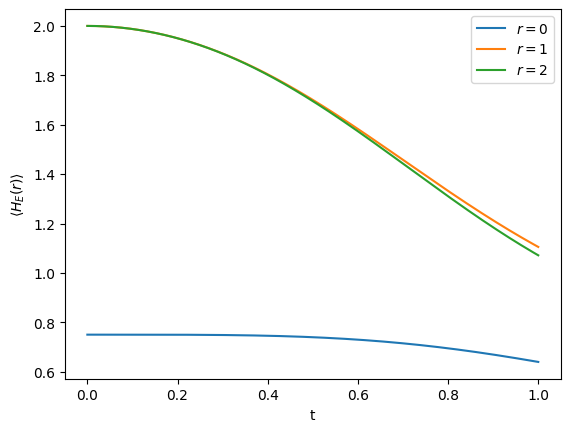

In [9]:
import matplotlib.pyplot as plt

plt.plot(tpoints, expval_ode, label=[f'$r={r}$' for r in range(num_sites - 1)])
plt.legend()
plt.xlabel('t')
plt.ylabel(r'$\langle H_E(r) \rangle$')

In [43]:
try: 
    with open("../savefiles/theoretical_calc.txt", mode="x") as f:
        for i in range(len(tpoints)):
            print(f'{tpoints[i]:.3f} {expval_ode[i][0]} {expval_ode[i][1]} {expval_ode[i][2]}', file=f)
    print("Calculation results have been saved.")
except FileExistsError:
    print("This file already exist.")

Calculation results have been saved.


## Execution on Quantinuum

In [10]:
from pytket.extensions.qiskit import qiskit_to_tk
from pytket.utils import gate_counts
import datetime

import qnexus as qnx
qnx.login()

Already logged in. Tokens are valid.


In [11]:
import qnexus as qnx

#project = qnx.projects.get_or_create(name="EmuStudy_4Site")
project = qnx.projects.get_or_create(name="LSH_LGT")
qnx.context.set_active_project(project)

In [12]:
from pytket.extensions.quantinuum import QuantinuumBackend

#backend_qnx = QuantinuumBackend('H1-2SC')
backend_qnx = QuantinuumBackend('H2-1')
#comp_circ = backend_qnx.default_compilation_pass(3).apply(qc_tket_initfull_nomeas)

In [13]:
from quantinuum_schemas.models.quantinuum_systems_noise import UserErrorParams

#device_name="H1-1LE"
device_name="H2-Emulator"
#device_name="H2-2SC"
config = qnx.QuantinuumConfig(device_name=device_name)
user_error_params = UserErrorParams(
    scale=0.9
)

# somehow following settings gives much different results with just scale=0.9
#user_error_params = UserErrorParams(
#    p1_scale=0.9,
#    p2_scale=0.9,
#    meas_scale=0.9,
#    init_scale=0.9,
#    memory_scale=0.9,
#    emission_scale=0.9,
#    crosstalk_scale=0.9,
#    leakage_scale=0.9
#)

conf_nonoise = qnx.QuantinuumConfig(device_name=device_name, noisy_simulation=False)
#myconfig = qnx.QuantinuumConfig(device_name=device_name, error_params=user_error_params)
myconfig = qnx.QuantinuumConfig(device_name=device_name)

#### Preparation for initial states
Redundant X gates are required to keep the ordering of qubits

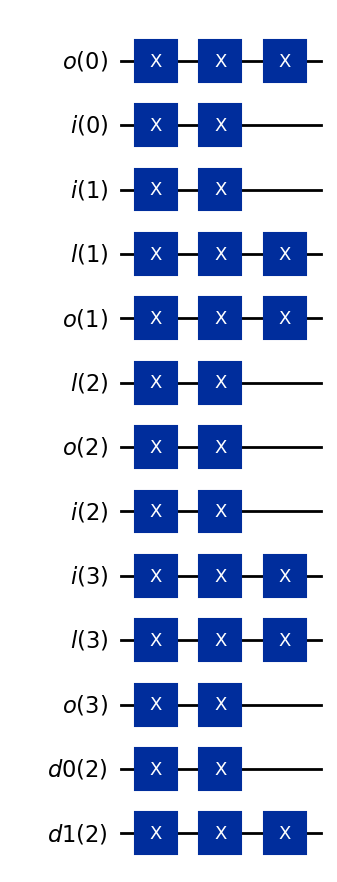

In [14]:
from qiskit.circuit import CircuitInstruction
from qiskit.circuit.library.standard_gates import XGate
from qiskit_ibm_runtime import SamplerV2 as Sampler
from qiskit import QuantumRegister, ClassicalRegister
from lsh_qudit.utils import QubitPlacement, sort_qubits, draw_circuit, clean_array, op_matrix

from pytket.extensions.qiskit import qiskit_to_tk
from pytket.utils import gate_counts
import datetime

full_qp = QubitPlacement(
    [('o', 0), ('i', 0)]
    + [('i', 1), ('l', 1), ('o', 1)]
    + [('l', 2), ('o', 2), ('i', 2)]
    + [('i', 3), ('l', 3), ('o', 3)]
    + [('d0', 2), ('d1', 2)]
)


#full_circuit = trotter_step_circuit(num_sites, dt, mu, x, qp=full_qp,
full_circuit = trotter_step_circuit(num_sites, time_step, mass_mu, interaction_x, qp=full_qp,
                                    max_left_flux=0, max_right_flux=1, with_barrier=True)


qregs = []
for name, isite in full_circuit[1].qubit_labels:
    qregs.append(QuantumRegister(1, name=f'{name}({isite})'))

qc = QuantumCircuit(*qregs)
qc.data.insert(0, CircuitInstruction(XGate(label=None), [0], []))
qc.data.insert(0, CircuitInstruction(XGate(label=None), [4], []))
qc.data.insert(0, CircuitInstruction(XGate(label=None), [3], []))
qc.data.insert(0, CircuitInstruction(XGate(label=None), [8], []))
qc.data.insert(0, CircuitInstruction(XGate(label=None), [9], []))
qc.data.insert(0, CircuitInstruction(XGate(label=None), [12], []))

for i in range(len(qregs)):
    qc.data.insert(0, CircuitInstruction(XGate(label=None), [i], []))
    qc.data.insert(0, CircuitInstruction(XGate(label=None), [i], []))

qc.draw("mpl")

In [17]:
from pytket.extensions.qiskit import qiskit_to_tk
from pytket.utils import gate_counts
import datetime
qnx.context.set_active_project(project)

qc_tket_initonly = qiskit_to_tk(qc)

jobname_suffix = datetime.datetime.now().strftime("%Y_%m_%d-%H-%M-%S")
ref = qnx.circuits.upload(circuit=qc_tket_initonly, name=f"test-{jobname_suffix}")
ref_compile_job = qnx.start_compile_job(
    programs=[ref],
    backend_config=myconfig,
    optimisation_level=0, # Compile the circuit without optimization, otherwise intentional redundant X gates will be removed
    name=f"compilation-4site-initonly-{jobname_suffix}",
)

#### Preparation for 1-step trotterized circuit
Compilation with initial states gives lower number of gates

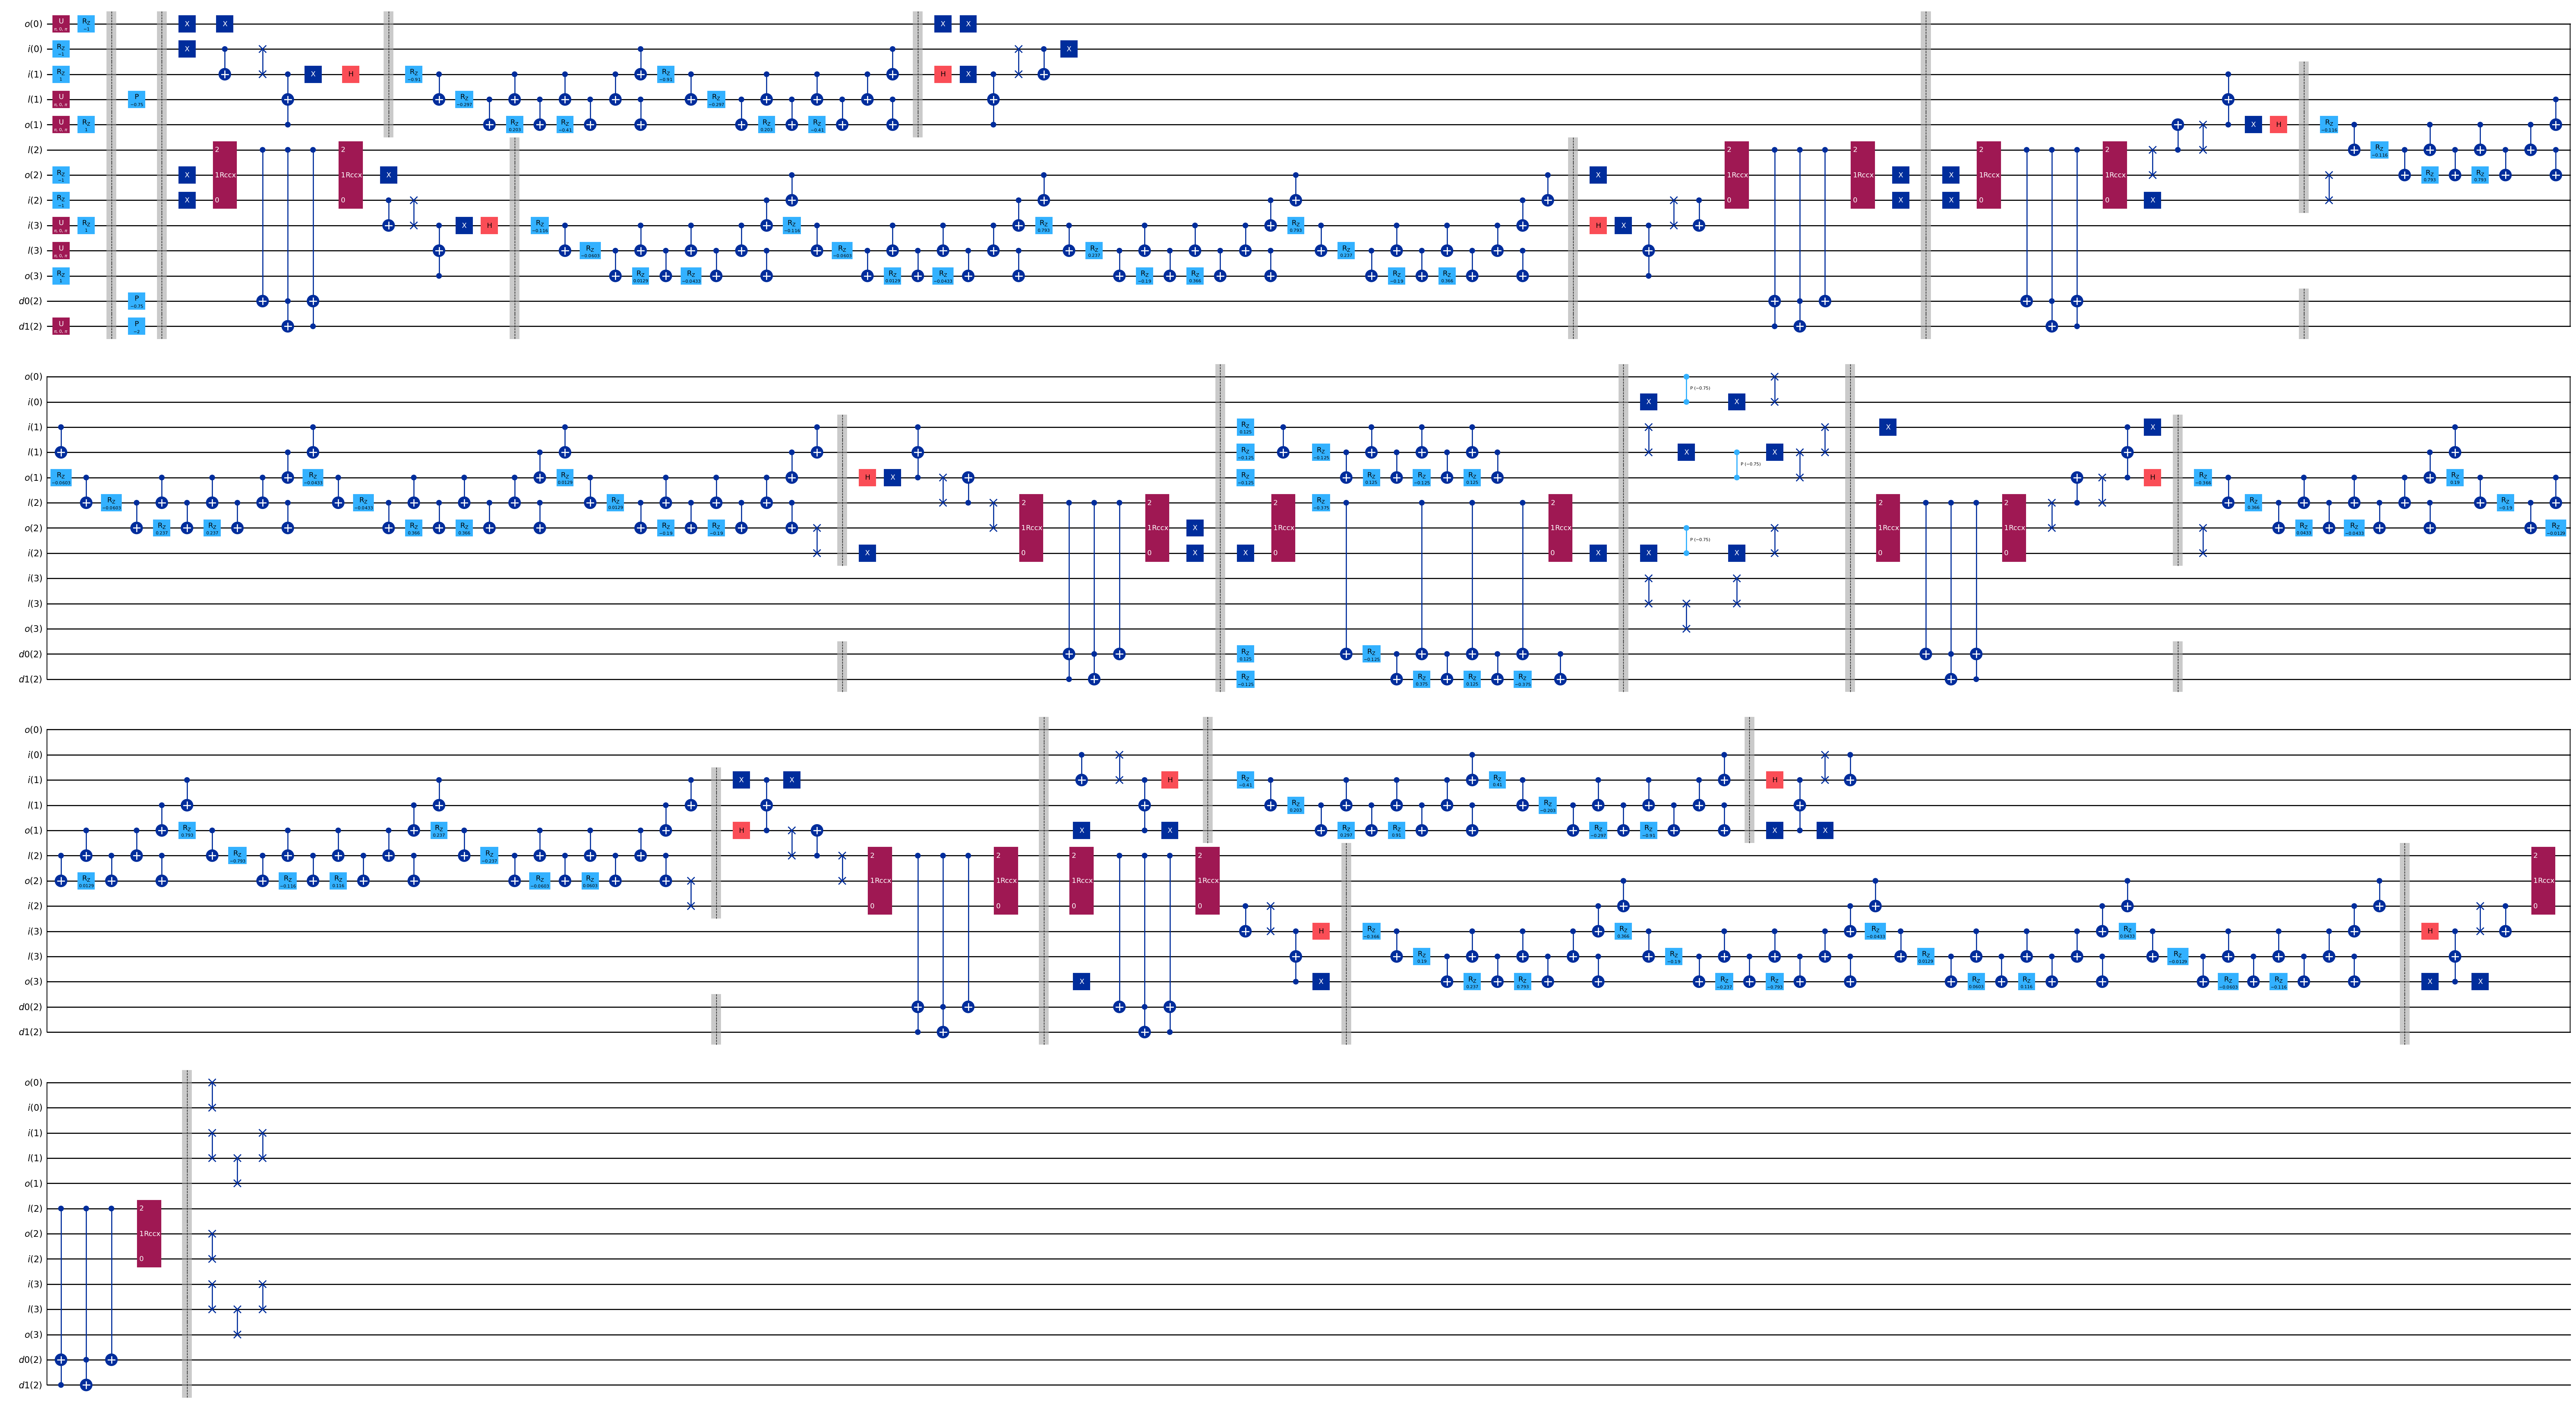

In [51]:
qc.decompose().draw("mpl", fold=100)

In [46]:
#full_circuit = trotter_step_circuit(num_sites, dt, mu, x, qp=full_qp,
full_circuit = trotter_step_circuit(num_sites, time_step, mass_mu, interaction_x, qp=full_qp,
                                    max_left_flux=0, max_right_flux=1, with_barrier=True)
precompiled = precompile_pm.run(full_circuit[0])
qregs = []
for name, isite in full_circuit[1].qubit_labels:
    qregs.append(QuantumRegister(1, name=f'{name}({isite})'))

qc = QuantumCircuit(*qregs)

qc.data.insert(0, CircuitInstruction(XGate(label=None), [0], []))
qc.data.insert(0, CircuitInstruction(XGate(label=None), [4], []))
qc.data.insert(0, CircuitInstruction(XGate(label=None), [3], []))
qc.data.insert(0, CircuitInstruction(XGate(label=None), [8], []))
qc.data.insert(0, CircuitInstruction(XGate(label=None), [9], []))
qc.data.insert(0, CircuitInstruction(XGate(label=None), [12], []))

qc.append(full_circuit[0].assign_parameters({mass_mu: mu, time_step: dt, interaction_x: 1.00}), range(13))
#qc.append(full_circuit[0].assign_parameters({mass_mu: mu, time_step: dt, interaction_x: 1.00}), range(13))
#qc.append(full_circuit[0].assign_parameters({mass_mu: mu, time_step: dt, interaction_x: 1.00}), range(13))
#qc.append(precompiled.assign_parameters({mass_mu: mu, time_step: dt, interaction_x: 1.00}), range(13))

#qc.measure_all()

In [49]:
from pytket.extensions.qiskit import qiskit_to_tk
from pytket.utils import gate_counts
import datetime
qnx.context.set_active_project(project)

qc_tket_initfull_nomeas = qiskit_to_tk(qc.decompose().decompose())

jobname_suffix = datetime.datetime.now().strftime("%Y_%m_%d-%H-%M-%S")
ref = qnx.circuits.upload(circuit=qc_tket_initfull_nomeas, name=f"test-{jobname_suffix}")
ref_compile_job = qnx.start_compile_job(
    programs=[ref],
    backend_config=myconfig,
    optimisation_level=3,
    name=f"compilation-4site-initfull-nomeas-{jobname_suffix}",
)

#### Preparation for the measurement part

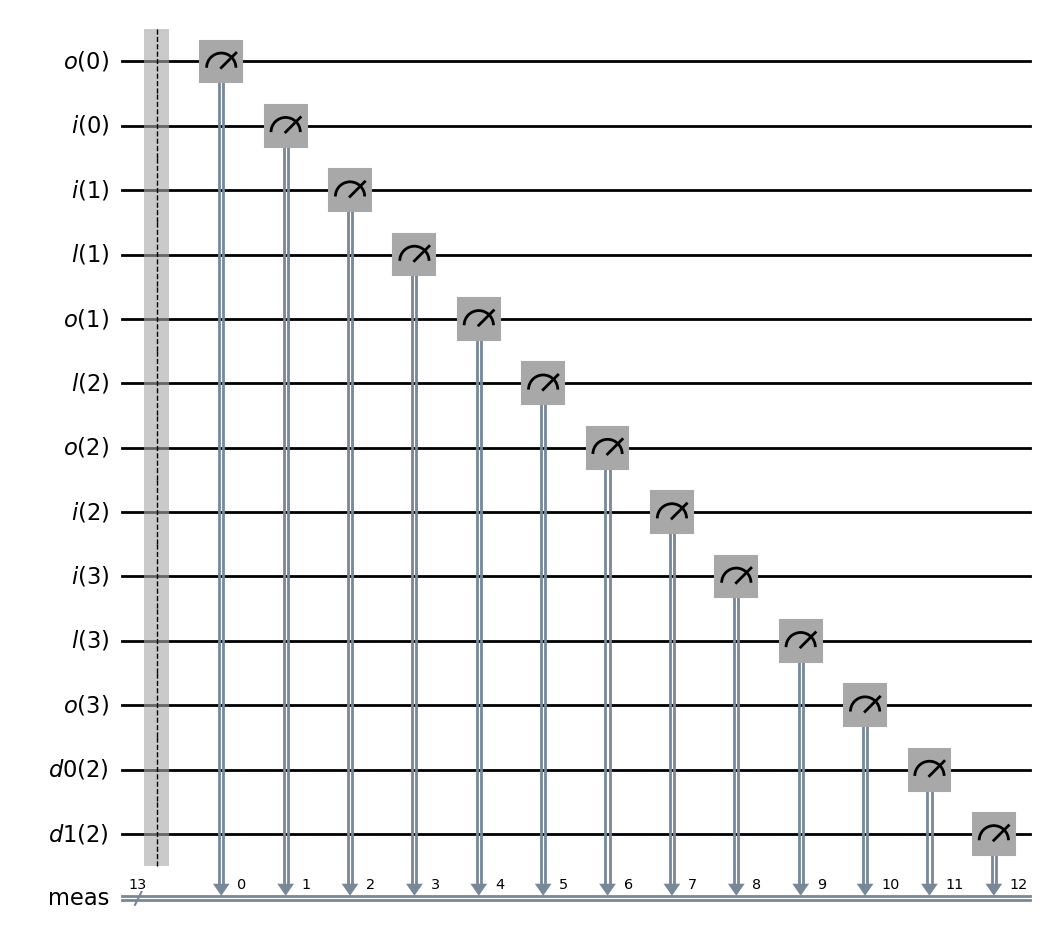

In [73]:
#full_circuit = trotter_step_circuit(num_sites, dt, mu, x, qp=full_qp,
full_circuit = trotter_step_circuit(num_sites, time_step, mass_mu, interaction_x, qp=full_qp,
                                    max_left_flux=0, max_right_flux=1, with_barrier=True)
precompiled = precompile_pm.run(full_circuit[0])
qregs = []
for name, isite in full_circuit[1].qubit_labels:
    qregs.append(QuantumRegister(1, name=f'{name}({isite})'))

qc = QuantumCircuit(*qregs)
qc.measure_all()
qc.decompose().draw("mpl")

In [74]:
from pytket.extensions.qiskit import qiskit_to_tk
from pytket.utils import gate_counts
import datetime
qnx.context.set_active_project(project)

qc_tket_measonly = qiskit_to_tk(qc.decompose())

jobname_suffix = datetime.datetime.now().strftime("%Y_%m_%d-%H-%M-%S")
ref = qnx.circuits.upload(circuit=qc_tket_measonly, name=f"test-{jobname_suffix}")
ref_compile_job = qnx.start_compile_job(
    programs=[ref],
    backend_config=myconfig,
    optimisation_level=0,
    name=f"compilation-4site-measonly-{jobname_suffix}",
)

### Circuit construction and job submission to Qnexus

In [15]:
# init-only
ref = qnx.client.jobs.get(id='07958d40-065f-443d-85d0-7910f705d480')
ref_compiled_circuit = qnx.jobs.results(ref)[0].get_output()
tket_init = ref_compiled_circuit.download_circuit()

# measurement only
ref = qnx.client.jobs.get(id='d4a5cede-02d2-4e90-a0e7-35a8fbe076c5')
ref_compiled_circuit = qnx.jobs.results(ref)[0].get_output()
tket_meas = ref_compiled_circuit.download_circuit()

In [41]:
import json
import datetime
import qnexus as qnx

TList = [0.2, 0.4, 0.6, 0.8, 1.0]
PROJECT_NAME = "LSH_LGT"
SAVE_FILE = f"../savefiles/qnexus_trotter_sf1_job_ids.json"
N_SHOTS = 1000

project = qnx.projects.get_or_create(name=PROJECT_NAME)
qnx.context.set_active_project(project)

job_records = []


full_circuit = trotter_step_circuit(num_sites, time_step, mass_mu, interaction_x, qp=full_qp,
                                    max_left_flux=0, max_right_flux=1, with_barrier=True)
qregs = []
for name, isite in full_circuit[1].qubit_labels:
    qregs.append(QuantumRegister(1, name=f'{name}({isite})'))


for tmax in TList:
    for i in range(6):
        nstep=i+1

        # Circuit construction
        qc = QuantumCircuit(*qregs)
        
        qc.data.insert(0, CircuitInstruction(XGate(label=None), [0], []))
        qc.data.insert(0, CircuitInstruction(XGate(label=None), [4], []))
        qc.data.insert(0, CircuitInstruction(XGate(label=None), [3], []))
        qc.data.insert(0, CircuitInstruction(XGate(label=None), [8], []))
        qc.data.insert(0, CircuitInstruction(XGate(label=None), [9], []))
        qc.data.insert(0, CircuitInstruction(XGate(label=None), [12], []))
        
        qc.append(full_circuit[0].assign_parameters({mass_mu: mu, time_step: tmax/nstep, interaction_x: 1.00}), range(13))
        
        qctket1step = qiskit_to_tk(qc.decompose().decompose())        
        backend_qnx.default_compilation_pass(3).apply(qctket1step)

        print(f"Tmax = {tmax}, nstep = {nstep}, dt = {tmax/nstep}, # of gates per step = {gate_counts(qctket1step)}")
        
        qctket = tket_init.copy()
        for _ in range(nstep):
            qctket.append(tket_init)
            qctket.append(qctket1step)
        qctket.append(tket_meas)
    
        timestamp = datetime.datetime.now().strftime("%Y_%m_%d-%H-%M-%S")
        circuit_name = f"test-initfull-{nstep}step-{timestamp}"
        compile_job_name = f"compilation-initfull-{nstep}step-{timestamp}"
        execute_job_name = f"execution-initfull-{nstep}step-{timestamp}"
    
        # upload
        circuit_ref = qnx.circuits.upload(
            circuit=qctket,
            project=project,
            name=circuit_name,
        )
    
        # compile
        compile_job_ref = qnx.start_compile_job(
            programs=[circuit_ref],
            backend_config=myconfig,
            optimisation_level=3,
            name=compile_job_name,
            project=project,
        )
    
        print(f"compile job submitted: {compile_job_ref.id}")
    
        # wait for compile
        qnx.jobs.wait_for(compile_job_ref)
    
        # get compiled circuit
        compiled_circuit_ref = qnx.jobs.results(compile_job_ref)[0].get_output()
    
        # execute
        execute_job_ref = qnx.start_execute_job(
            programs=[compiled_circuit_ref],
            n_shots=[N_SHOTS],
            backend_config=myconfig,
            name=execute_job_name,
            project=project,
        )
    
        print(f"execute job submitted: {execute_job_ref.id}")
    
        # save job ID
        job_records.append({
            "tmax": tmax,
            "nstep": nstep,
            "execute_job_id": str(execute_job_ref.id),
            "execute_job_name": execute_job_name,
            "circuit_name": circuit_name,
            "shots": N_SHOTS,
        })

# save jobID as a json file
with open(SAVE_FILE, "w", encoding="utf-8") as f:
    json.dump(job_records, f, indent=2, ensure_ascii=False)

print(f"Saved execute job IDs to {SAVE_FILE}")

Tmax = 0.2, nstep = 1, dt = 0.2, # of gates per step = Counter({OpType.PhasedX: 296, OpType.ZZPhase: 226, OpType.Rz: 13})
compile job submitted: fd40841d-aef5-4346-9c11-e27e2a3a23ee
execute job submitted: 4f3a5ff6-8bea-4f04-80ff-813f83ab494a
Tmax = 0.2, nstep = 2, dt = 0.1, # of gates per step = Counter({OpType.PhasedX: 296, OpType.ZZPhase: 226, OpType.Rz: 13})
compile job submitted: 06113631-11ab-4a1d-9a36-305671d75b6c
execute job submitted: 958b63ce-a0a2-42e5-a40f-9bc57ce8063c
Tmax = 0.2, nstep = 3, dt = 0.06666666666666667, # of gates per step = Counter({OpType.PhasedX: 296, OpType.ZZPhase: 226, OpType.Rz: 13})
compile job submitted: 010bb374-e75e-410c-bd68-ff8385bfae71
execute job submitted: fd0c7858-7597-4200-adeb-0764b131394e
Tmax = 0.2, nstep = 4, dt = 0.05, # of gates per step = Counter({OpType.PhasedX: 296, OpType.ZZPhase: 226, OpType.Rz: 13})
compile job submitted: 3fb848c2-a376-4060-b9f4-1f7fd445666c
execute job submitted: bed68f44-7103-4cba-8277-1d8e5eed70b2
Tmax = 0.2, nst

#### Test cicuits initialized with zero states

In [16]:
import json
import datetime
import qnexus as qnx

TList = [0.2, 0.4, 0.6, 0.8, 1.0]
PROJECT_NAME = "LSH_LGT"
SAVE_FILE = f"../savefiles/qnexus_trotter_sf1_zeroinit_job_ids.json"
N_SHOTS = 1000

project = qnx.projects.get_or_create(name=PROJECT_NAME)
qnx.context.set_active_project(project)

job_records = []


full_circuit = trotter_step_circuit(num_sites, time_step, mass_mu, interaction_x, qp=full_qp,
                                    max_left_flux=0, max_right_flux=1, with_barrier=True)
qregs = []
for name, isite in full_circuit[1].qubit_labels:
    qregs.append(QuantumRegister(1, name=f'{name}({isite})'))


for tmax in TList:
    for i in range(6):
        nstep=i+1

        # Circuit construction
        qc = QuantumCircuit(*qregs)
        
        qc.data.insert(0, CircuitInstruction(XGate(label=None), [0], []))
        qc.data.insert(0, CircuitInstruction(XGate(label=None), [4], []))
        qc.data.insert(0, CircuitInstruction(XGate(label=None), [3], []))
        qc.data.insert(0, CircuitInstruction(XGate(label=None), [8], []))
        qc.data.insert(0, CircuitInstruction(XGate(label=None), [9], []))
        qc.data.insert(0, CircuitInstruction(XGate(label=None), [12], []))
        
        qc.append(full_circuit[0].assign_parameters({mass_mu: mu, time_step: tmax/nstep, interaction_x: 1.00}), range(13))
        
        qctket1step = qiskit_to_tk(qc.decompose().decompose())        
        backend_qnx.default_compilation_pass(3).apply(qctket1step)

        print(f"Tmax = {tmax}, nstep = {nstep}, dt = {tmax/nstep}, # of gates per step = {gate_counts(qctket1step)}")
        
        qctket = tket_init.copy()
        qctket.append(qctket1step)
        for _ in range(nstep-1):
            qctket.append(tket_init)
            qctket.append(qctket1step)
        qctket.append(tket_meas)
       
        timestamp = datetime.datetime.now().strftime("%Y_%m_%d-%H-%M-%S")
        circuit_name = f"test-initfull-{nstep}step-{timestamp}"
        compile_job_name = f"compilation-initfull-{nstep}step-{timestamp}"
        execute_job_name = f"execution-initfull-{nstep}step-{timestamp}"
    
        # upload
        circuit_ref = qnx.circuits.upload(
            circuit=qctket,
            project=project,
            name=circuit_name,
        )
    
        # compile
        compile_job_ref = qnx.start_compile_job(
            programs=[circuit_ref],
            backend_config=myconfig,
            optimisation_level=3,
            name=compile_job_name,
            project=project,
        )
    
        print(f"compile job submitted: {compile_job_ref.id}")
    
        # wait for compile
        qnx.jobs.wait_for(compile_job_ref)
    
        # get compiled circuit
        compiled_circuit_ref = qnx.jobs.results(compile_job_ref)[0].get_output()
    
        # execute
        execute_job_ref = qnx.start_execute_job(
            programs=[compiled_circuit_ref],
            n_shots=[N_SHOTS],
            backend_config=myconfig,
            name=execute_job_name,
            project=project,
        )
    
        print(f"execute job submitted: {execute_job_ref.id}")
    
        # save job ID
        job_records.append({
            "tmax": tmax,
            "nstep": nstep,
            "execute_job_id": str(execute_job_ref.id),
            "execute_job_name": execute_job_name,
            "circuit_name": circuit_name,
            "shots": N_SHOTS,
        })

# save jobID as a json file
with open(SAVE_FILE, "w", encoding="utf-8") as f:
    json.dump(job_records, f, indent=2, ensure_ascii=False)

print(f"Saved execute job IDs to {SAVE_FILE}")

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.
Tmax = 0.2, nstep = 1, dt = 0.2, # of gates per step = Counter({OpType.PhasedX: 296, OpType.ZZPhase: 226, OpType.Rz: 13})
compile job submitted: d12d1d7d-a0d8-40fd-9ecf-420725c4b879
execute job submitted: 8f53f6f2-f54c-40c0-bc2b-c7d6a94d1af3
Tmax = 0.2, nstep = 2, dt = 0.1, # of gates per step = Counter({OpType.PhasedX: 296, OpType.ZZPhase: 226, OpType.Rz: 13})
compile job submitted: 6464d61f-5fd5-4d59-bd24-2e0918be2d15
execute job submitted: c33147e5-23b7-4e6e-b080-29757998bcfb
Tmax = 0.2, nstep = 3, dt = 0.06666666666666667, # of gates per step = Counter({OpType.PhasedX: 296, OpType.ZZPhase: 226, OpType.Rz: 13})
compile job submitted: 4561c08c-713d-4e65-86e5-6d6f0e1d58f7
execute job submitted: 8953645b-e7ed-4b4b-b55e-7058cefbecdf
Tmax = 0.2, nstep = 4, dt = 0.05, # of gates per step = Counter({OpType.PhasedX: 296, OpType.ZZPhase: 22

## Dump observables of execution results

In [18]:
import json
import qnexus as qnx

PROJECT_NAME = "LSH_LGT"
SAVE_FILE = "../savefiles/qnexus_trotter_sf1_job_ids.json"

project = qnx.projects.get_or_create(name=PROJECT_NAME)
qnx.context.set_active_project(project)

with open(SAVE_FILE, "r", encoding="utf-8") as f:
    job_records = json.load(f)

empirical_distributions = [None] * 6

for rec in job_records:
    tmax   = rec["tmax"]
    nstep  = rec["nstep"]
    job_id = rec["execute_job_id"]

    print(f"Fetching result for tmax={tmax}, nstep={nstep}, job_id={job_id}")

    execute_job_ref = qnx.client.jobs.get(id=job_id)

    qnx.jobs.wait_for(execute_job_ref)

    ref_result = qnx.jobs.results(execute_job_ref)[0]
    backend_result = ref_result.download_result()
    dist = backend_result.get_empirical_distribution()

    empirical_distributions[nstep-1] = dist

    DumpInfoQnx(dist, f'../savefiles/{device_name}_trotterT{int(10*tmax)}_sf1_{nstep}step.txt')
    
print("Done.")
#print(empirical_distributions)

Fetching result for tmax=0.2, nstep=1, job_id=4f3a5ff6-8bea-4f04-80ff-813f83ab494a
Fetching result for tmax=0.2, nstep=2, job_id=958b63ce-a0a2-42e5-a40f-9bc57ce8063c
Fetching result for tmax=0.2, nstep=3, job_id=fd0c7858-7597-4200-adeb-0764b131394e
Fetching result for tmax=0.2, nstep=4, job_id=bed68f44-7103-4cba-8277-1d8e5eed70b2
Fetching result for tmax=0.2, nstep=5, job_id=ae255b4b-6e77-4673-9ca4-be84cf393ecf
Fetching result for tmax=0.2, nstep=6, job_id=3aaa3329-205b-4f10-971c-c770116c330b
Fetching result for tmax=0.4, nstep=1, job_id=d69e88af-ce69-4910-bcb1-d703611a8dae
Fetching result for tmax=0.4, nstep=2, job_id=e7422144-3b76-4159-8c11-6207d6c3356f
Fetching result for tmax=0.4, nstep=3, job_id=208fa3fd-12ad-4ba5-b9f5-cfc5ecb57f70
Fetching result for tmax=0.4, nstep=4, job_id=f05fc4e1-1012-48c8-9519-1d4964c65b54
Fetching result for tmax=0.4, nstep=5, job_id=c3438be0-e104-4f48-b68a-4e41dbe96572
Fetching result for tmax=0.4, nstep=6, job_id=aa6c74db-37e8-4278-a626-3dfd9ce2d236
Fetc

In [44]:
import json
import qnexus as qnx

PROJECT_NAME = "LSH_LGT"
SAVE_FILE = "../savefiles/qnexus_trotter_sf1_zeroinit_job_ids.json"

project = qnx.projects.get_or_create(name=PROJECT_NAME)
qnx.context.set_active_project(project)

with open(SAVE_FILE, "r", encoding="utf-8") as f:
    job_records = json.load(f)

empirical_distributions = [None] * 6

for rec in job_records:
    tmax   = rec["tmax"]
    nstep  = rec["nstep"]
    job_id = rec["execute_job_id"]

    print(f"Fetching result for tmax={tmax}, nstep={nstep}, job_id={job_id}")

    execute_job_ref = qnx.client.jobs.get(id=job_id)

    qnx.jobs.wait_for(execute_job_ref)

    ref_result = qnx.jobs.results(execute_job_ref)[0]
    backend_result = ref_result.download_result()
    dist = backend_result.get_empirical_distribution()

    empirical_distributions[nstep-1] = dist

    DumpInfoQnx(dist, f'../savefiles/{device_name}_trotterT{int(10*tmax)}_sf1_zeroinit_{nstep}step.txt')
    
print("Done.")
#print(empirical_distributions)

Fetching result for tmax=0.2, nstep=1, job_id=8f53f6f2-f54c-40c0-bc2b-c7d6a94d1af3
Fetching result for tmax=0.2, nstep=2, job_id=c33147e5-23b7-4e6e-b080-29757998bcfb
Fetching result for tmax=0.2, nstep=3, job_id=8953645b-e7ed-4b4b-b55e-7058cefbecdf
Fetching result for tmax=0.2, nstep=4, job_id=5d863b9b-4a3a-4a91-b10f-391ea23abeea
Fetching result for tmax=0.2, nstep=5, job_id=e93c534e-ac99-4dc7-98a0-44f16c0883e3
Fetching result for tmax=0.2, nstep=6, job_id=9277c149-bee8-4ae4-8ee8-f355fe8c8830
Fetching result for tmax=0.4, nstep=1, job_id=517ea27e-af2b-4aeb-b9af-1ec5eec7e0bc
Fetching result for tmax=0.4, nstep=2, job_id=0c9cb9a2-adea-4f35-9201-4ad4d4d5e85c
Fetching result for tmax=0.4, nstep=3, job_id=44123939-9a15-4d14-bc33-7f6eceb56732
Fetching result for tmax=0.4, nstep=4, job_id=c90c3341-0336-41f4-b9e1-528fdaaccbbe
Fetching result for tmax=0.4, nstep=5, job_id=666ff6c8-4892-44d1-a3e1-db23ebba1fcd
Fetching result for tmax=0.4, nstep=6, job_id=d04933ad-cbf2-4014-9259-df54b70fc5e8
Fetc

## Plotting code

In [19]:
!root -l -b -q -n '../macro/plot_for_paper_H2_quantinuum.C'


Processing ../macro/plot_for_paper_H2_quantinuum.C...
Load File: ../savefiles/H2-Emulator_initfull_sf1_zeroinit_1step.txt
iStep = 1, j = 0, vObs =  0.01575
iStep = 1, j = 1, vObs =  0.113
iStep = 1, j = 2, vObs =  0.306
iStep = 1, j = 3, vObs =  0.068
iStep = 1, j = 4, vObs =  0.02625
Load File: ../savefiles/H2-Emulator_initfull_sf1_zeroinit_2step.txt
iStep = 2, j = 0, vObs =  0.05925
iStep = 2, j = 1, vObs =  0.2165
iStep = 2, j = 2, vObs =  0.574
iStep = 2, j = 3, vObs =  0.1435
iStep = 2, j = 4, vObs =  0.03975
Load File: ../savefiles/H2-Emulator_initfull_sf1_zeroinit_3step.txt
iStep = 3, j = 0, vObs =  0.081
iStep = 3, j = 1, vObs =  0.27325
iStep = 3, j = 2, vObs =  0.78425
iStep = 3, j = 3, vObs =  0.1945
iStep = 3, j = 4, vObs =  0.05025
Load File: ../savefiles/H2-Emulator_initfull_sf1_zeroinit_4step.txt
iStep = 4, j = 0, vObs =  0.10575
iStep = 4, j = 1, vObs =  0.35625
iStep = 4, j = 2, vObs =  0.96725
iStep = 4, j = 3, vObs =  0.32475
iStep = 4, j = 4, vObs =  0.07125
Load F